In [27]:
import torch
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
#print(f"Using device: {device}")


In [28]:
words = open('names.txt', 'r').read().splitlines()
split1 = int(len(words)*0.8)
split2 = int(len(words)*0.9)
words_train = words[:split1]
words_dev = words[split1:split2]
words_test = words[split2:]

chars = sorted(list(set(''.join(words))))

stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

4.225663661956787
4.1872711181640625
3.7379589080810547
3.7666015625
3.451751470565796
3.5384268760681152
3.26332950592041
3.3829879760742188
3.12960147857666
3.277867078781128
3.0323128700256348
3.197991371154785
2.9568288326263428
3.1350436210632324
2.895462989807129
3.0821139812469482
2.8444008827209473
3.037597179412842
2.801332950592041
2.9995481967926025
2.76466965675354
2.9669010639190674
2.7332284450531006
2.938654899597168
2.706082820892334
2.9140613079071045
2.682478427886963
2.892467975616455
2.661789655685425
2.8733391761779785
2.643500566482544
2.856227159500122
2.6271867752075195
2.840770721435547
2.612506151199341
2.8266830444335938
2.599186658859253
2.8137433528900146
2.587015151977539
2.8017828464508057
2.5758237838745117
2.7906694412231445
2.5654804706573486
2.780303716659546
2.555880069732666
2.7706050872802734
2.5469372272491455
2.7615084648132324
2.538583278656006
2.752960205078125
2.5307581424713135
2.74491286277771
2.5234134197235107
2.737327814102173
2.516506195

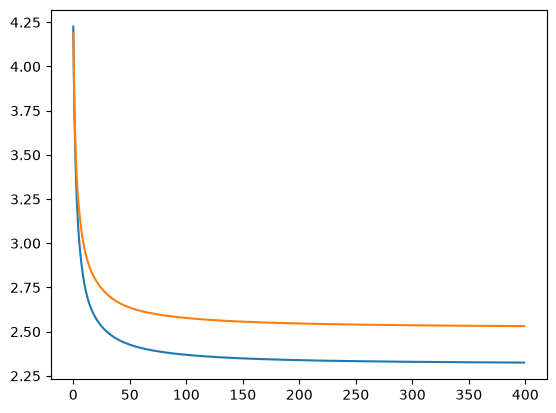

In [38]:


xs1_train, xs2_train, ys_train, xs1_test, xs2_test, ys_test = [],[],[],[],[],[]
for w in words_train: 
    chs = ['.','.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs,chs[1:], chs[2:]):
        xs1_train.append(stoi[ch1])
        xs2_train.append(stoi[ch2])
        ys_train.append(stoi[ch3])
for w in words_test: 
    chs = ['.','.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs,chs[1:], chs[2:]):
        xs1_test.append(stoi[ch1])
        xs2_test.append(stoi[ch2])
        ys_test.append(stoi[ch3])

#init
xs1_train = torch.tensor(xs1_train)
xs2_train = torch.tensor(xs2_train)
ys_train = torch.tensor(ys_train)
xs1_test = torch.tensor(xs1_test)
xs2_test = torch.tensor(xs2_test)
ys_test = torch.tensor(ys_test)
g = torch.Generator().manual_seed(1)
xenc1_train = F.one_hot(xs1_train,num_classes=27).float()
xenc2_train = F.one_hot(xs2_train,num_classes=27).float()
xenc_train = torch.cat((xenc1_train,xenc2_train),dim=1)

xenc1_test = F.one_hot(xs1_test,num_classes=27).float()
xenc2_test = F.one_hot(xs2_test,num_classes=27).float()
xenc_test = torch.cat((xenc1_test,xenc2_test),dim=1)
W = torch.randn((54,27), generator=g, requires_grad=True)
num_train = xs1_train.nelement()
num_test = xs1_test.nelement()

loss_train = []
loss_test = []

for k in range(400):
    #train forward
    logits_train = xenc_train @ W
    counts_train = logits_train.exp()
    probs_train = counts_train / counts_train.sum(1,keepdims=True)
    l_train = -probs_train[torch.arange(num_train), ys_train].log().mean() + 0.01*(W**2).mean()
    print(l_train.item())
    loss_train.append(l_train.item())


    #test forward
    logits_test = xenc_test @ W
    counts_test = logits_test.exp()
    probs_test = counts_test / counts_test.sum(1,keepdims=True)
    l_test = -probs_test[torch.arange(num_test), ys_test].log().mean() + 0.01*(W**2).mean()
    print(l_test.item())
    loss_test.append(l_test.item())

    #backward
    W.grad = None
    l_train.backward()

    #update
    W.data += -25 * W.grad
plt.plot(loss_train)
plt.plot(loss_test)
print(f'train loss - {l}; test loss - {l_test}')


In [35]:
g = torch.Generator().manual_seed(1)
for k in range(10):
    out = []
    ix1 =  0
    ix2 =  0

    while True:
        xenc1 = F.one_hot(torch.tensor([ix1]),num_classes=27).float()
        xenc2 = F.one_hot(torch.tensor([ix2]),num_classes=27).float()
        xenc = torch.cat((xenc1,xenc2),dim=1)
        logits = xenc @ W
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdims=True)

        ix = torch.multinomial(probs, num_samples=1,replacement = True, generator = g).item()
        if ix == 0:
            break
        out.append(itos[ix])

        ix1 = ix2
        ix2 = ix
    print(''.join(out))

aha
ele
lia
aldel
xalisse
del
bemartti
rielcirlenn
madlais
honera


Using device: mps
